In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


#Load MNIST Dataset

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.94MB/s]


Define VAE

In [ ]:
class VAE(nn.Module):

    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

VAE Loss Function

In [ ]:
def vae_loss(recon_x, x, mu, logvar):

    BCE = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    )

    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD

Train VAE

In [ ]:
vae = VAE().to(device)

optimizer = optim.Adam(
    vae.parameters(),
    lr=1e-3
)

epochs = 10

for epoch in range(epochs):

    vae.train()
    total_loss = 0

    for images, _ in train_loader:

        images = images.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = vae(images)

        loss = vae_loss(
            recon,
            images,
            mu,
            logvar
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss={total_loss/len(train_loader.dataset):.4f}"
    )

Epoch 1/10, Loss=164.1226
Epoch 2/10, Loss=120.8921
Epoch 3/10, Loss=114.3025
Epoch 4/10, Loss=111.4065
Epoch 5/10, Loss=109.6573
Epoch 6/10, Loss=108.5201
Epoch 7/10, Loss=107.7075
Epoch 8/10, Loss=107.0819
Epoch 9/10, Loss=106.6182
Epoch 10/10, Loss=106.1982


Generate Synthetic Digits

In [ ]:
num_synthetic = 10000
latent_dim = 20

vae.eval()

with torch.no_grad():

    z = torch.randn(
        num_synthetic,
        latent_dim
    ).to(device)

    synthetic_images = vae.decode(z)

synthetic_images = synthetic_images.view(
    -1,
    1,
    28,
    28
).cpu()

Visualize Generated Digits

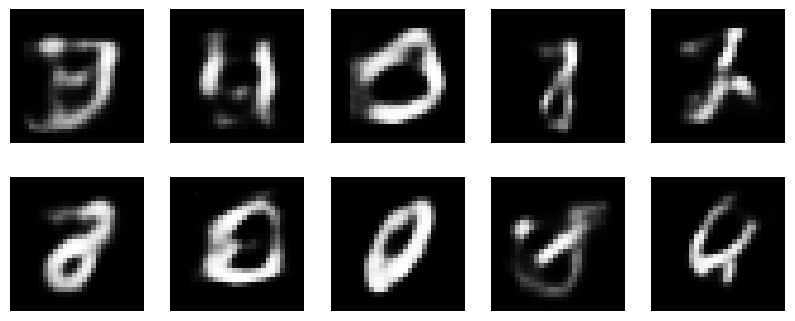

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        synthetic_images[i].squeeze(),
        cmap='gray'
    )

    ax.axis('off')

plt.show()

Create Labels for Synthetic Data

In [ ]:
synthetic_labels = torch.randint(
    0,
    10,
    (num_synthetic,)
)

synthetic_dataset = TensorDataset(
    synthetic_images,
    synthetic_labels
)

Augment Dataset

In [ ]:
augmented_dataset = ConcatDataset([
    train_dataset,
    synthetic_dataset
])

augmented_loader = DataLoader(
    augmented_dataset,
    batch_size=128,
    shuffle=True
)

In [ ]:
# Convert original MNIST dataset to TensorDataset

train_images = train_dataset.data.float() / 255.0
train_images = train_images.unsqueeze(1)

train_labels = train_dataset.targets.long()

original_dataset = TensorDataset(
    train_images,
    train_labels
)

# Synthetic dataset

synthetic_dataset = TensorDataset(
    synthetic_images.float(),
    synthetic_labels.long()
)

# Combine datasets

augmented_dataset = ConcatDataset([
    original_dataset,
    synthetic_dataset
])

augmented_loader = DataLoader(
    augmented_dataset,
    batch_size=128,
    shuffle=True
)

CNN Classifer

In [ ]:
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                64 * 7 * 7,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                10
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.classifier(x)

        return x

Train CNN

In [ ]:
cnn = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn.parameters(),
    lr=0.001
)

epochs = 5

for epoch in range(epochs):

    cnn.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in augmented_loader:

        images = images.float().to(device)
        labels = labels.long().to(device)

        optimizer.zero_grad()

        outputs = cnn(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / len(augmented_loader)

    epoch_acc = (
        100 * correct / total
    )

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_acc:.2f}%"
    )

Epoch [1/5] Loss: 0.6709 Accuracy: 79.94%
Epoch [2/5] Loss: 0.4236 Accuracy: 85.01%
Epoch [3/5] Loss: 0.4014 Accuracy: 85.51%
Epoch [4/5] Loss: 0.3858 Accuracy: 85.81%
Epoch [5/5] Loss: 0.3786 Accuracy: 85.99%


Evaluate on Test Data

In [ ]:
cnn.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.float().to(device)
        labels = labels.long().to(device)

        outputs = cnn(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_accuracy = (
    100 * correct / total
)

print(
    f"Test Accuracy: "
    f"{test_accuracy:.2f}%"
)

Test Accuracy: 99.07%


Confusion matrix

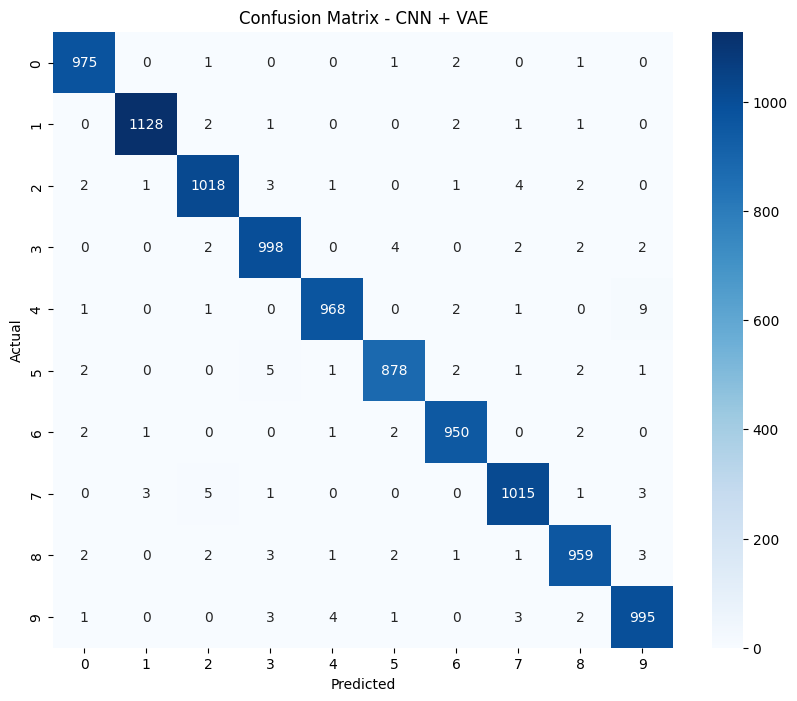

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = np.array([
[975,0,1,0,0,1,2,0,1,0],
[0,1128,2,1,0,0,2,1,1,0],
[2,1,1018,3,1,0,1,4,2,0],
[0,0,2,998,0,4,0,2,2,2],
[1,0,1,0,968,0,2,1,0,9],
[2,0,0,5,1,878,2,1,2,1],
[2,1,0,0,1,2,950,0,2,0],
[0,3,5,1,0,0,0,1015,1,3],
[2,0,2,3,1,2,1,1,959,3],
[1,0,0,3,4,1,0,3,2,995]
])

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN + VAE")
plt.show()